Simple Neural Network Model


In [1]:
# Add a 5th encoder block (enc5) and corresponding decoder block (dec4)
# Use base_channels = 64 → scales to 64 → 128 → 256 → 512 → 1024 channels

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

class ConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)
    
def pad_to_match(tensor_to_pad, target_tensor):
    diff = target_tensor.size(2) - tensor_to_pad.size(2)
    if diff > 0:
        pad_left = diff // 2
        pad_right = diff - pad_left
        tensor_to_pad = F.pad(tensor_to_pad, (pad_left, pad_right))
    elif diff < 0:
        # Optional: If tensor_to_pad is longer, crop it
        crop_left = (-diff) // 2
        crop_right = crop_left + target_tensor.size(2)
        tensor_to_pad = tensor_to_pad[:, :, crop_left:crop_right]
    return tensor_to_pad

class UNet1D(nn.Module):
    def __init__(self, in_channels=4, base_channels=64, out_channels=3):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock1D(in_channels, base_channels)                        # [B, 64, L]
        self.pool1 = nn.MaxPool1d(2)                                                # [B, 64, L/2]

        self.enc2 = ConvBlock1D(base_channels, base_channels * 2)                  # [B, 128, L/2]
        self.pool2 = nn.MaxPool1d(2)                                                # [B, 128, L/4]

        self.enc3 = ConvBlock1D(base_channels * 2, base_channels * 4)              # [B, 256, L/4]
        self.pool3 = nn.MaxPool1d(2)                                                # [B, 256, L/8]

        self.enc4 = ConvBlock1D(base_channels * 4, base_channels * 8)              # [B, 512, L/8]
        self.pool4 = nn.MaxPool1d(2)                                                # [B, 512, L/16]

        self.enc5 = ConvBlock1D(base_channels * 8, base_channels * 16)             # [B, 1024, L/16]

        # Decoder
        self.up4 = nn.ConvTranspose1d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)   # [B, 512, L/8]
        self.dec4 = ConvBlock1D(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose1d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)    # [B, 256, L/4]
        self.dec3 = ConvBlock1D(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose1d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)    # [B, 128, L/2]
        self.dec2 = ConvBlock1D(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose1d(base_channels * 2, base_channels, kernel_size=2, stride=2)        # [B, 64, L]
        self.dec1 = ConvBlock1D(base_channels * 2, base_channels)

        # Final output
        self.final = nn.Conv1d(base_channels, out_channels, kernel_size=9, padding=4)

    def forward(self, x):
        e1 = self.enc1(x)                          # [B, 64, L]
        e2 = self.enc2(self.pool1(e1))             # [B, 128, L/2]
        e3 = self.enc3(self.pool2(e2))             # [B, 256, L/4]
        e4 = self.enc4(self.pool3(e3))             # [B, 512, L/8]
        e5 = self.enc5(self.pool4(e4))             # [B, 1024, L/16]

        d4 = self.up4(e5)                          # [B, 512, L/8]
        d4 = pad_to_match(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)                          # [B, 256, L/4]
        d3 = pad_to_match(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)                          # [B, 128, L/2]
        d2 = pad_to_match(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)                          # [B, 64, L]
        d1 = pad_to_match(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)                      # [B, 3, L]


Dataset Loader

In [2]:
import pandas as pd
import torch
from torch.utils.data import DataLoader

class RNADataset(torch.utils.data.Dataset):
    def __init__(self, df, window_size=None):
        # window_size=None means full sequence, or you can set a fixed chunk size
        self.data = []
        self.labels = []
        mapping = {'A': [1, 0, 0, 0], 'U': [0, 1, 0, 0], 'C': [0, 0, 1, 0], 'G': [0, 0, 0, 1]}
        
        # Group by molecules, to get full sequences
        for mol_id, group in df.groupby('mol_id'):
            group = group.sort_values('resid').reset_index(drop=True)
            seq = group['resname'].values
            coords = group[['x_1', 'y_1', 'z_1']].values
            
            # Encode entire sequence as one tensor: shape (4, seq_len)
            encoded_seq = torch.tensor([mapping.get(nuc, [0,0,0,0]) for nuc in seq]).T.float()
            
            # Coordinates as tensor: shape (3, seq_len)
            coords_seq = torch.tensor(coords).T.float()
            
            self.data.append(encoded_seq)
            self.labels.append(coords_seq)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return (4, seq_len), (3, seq_len)
        return self.data[idx], self.labels[idx]

# Now create dataset and loader
df = pd.read_csv('RNA_data.csv')

dataset = RNADataset(df)
loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=lambda x: (
    torch.nn.utils.rnn.pad_sequence([item[0].T for item in x], batch_first=True).permute(0,2,1),  # pad inputs
    torch.nn.utils.rnn.pad_sequence([item[1].T for item in x], batch_first=True).permute(0,2,1)   # pad labels
))

# Explanation:
# - item[0].T to (seq_len, 4) for padding
# - pad_sequence to pad sequences to max length in batch
# - permute back to (batch, 4, seq_len)
# Same for labels (3 channels)



Training the Model

In [3]:
model = UNet1D()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
def tm_score_approx(pred, target, d0=1.24):
    """
    pred, target: (B, N, 3) coordinates
    d0: normalization constant
    """
    dists = torch.norm(pred - target, dim=-1)  # (B, N)
    score = 1 / (1 + (dists / d0) ** 2)
    return score.mean()  # average over residues and batch

num_epochs = 2
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_tm = 0.0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)  # (B, 4, L), (B, 3, L)

        optimizer.zero_grad()
        outputs = model(inputs)  # (B, 3, L)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # TM-score expects (B, L, 3)
        tm = tm_score_approx(outputs.permute(0, 2, 1), targets.permute(0, 2, 1))

        total_loss += loss.item()
        total_tm += tm.item()

    avg_loss = total_loss / len(loader)
    avg_tm = total_tm / len(loader)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, TM-score ≈ {avg_tm:.4f}")


Epoch 1/2 - Loss: 2303.5262, TM-score ≈ 0.8447
Epoch 2/2 - Loss: 1536.9005, TM-score ≈ 0.8476


In [4]:
# Save the model
torch.save(model.state_dict(), 'RNA_unet4.pt')
# Initialize and load the model
model = UNet1D()
model.load_state_dict(torch.load('RNA_unet4.pt'))
model.eval()  # Set to evaluation mode


UNet1D(
  (enc1): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(4, 64, kernel_size=(9,), stride=(1,), padding=(4,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(64, 64, kernel_size=(9,), stride=(1,), padding=(4,))
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(128, 128, kernel_size=(9,), stride=(1,), padding=(4,))
      (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool

Evaluate or Visualize
Compare predicted vs. actual 3D coordinates using RMSD, or visualize with matplotlib

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import random
import numpy as np
from collections import defaultdict

# Load the validation file
val_df = pd.read_csv('./data/validation_labels.csv')  # Assuming this is the file name

# Extract base mol_name and res_index
#val_df['mol_base'] = val_df['ID'].apply(lambda x: '_'.join(x.split('_')[:2]))
#val_df['res_index'] = val_df['ID'].apply(lambda x: int(x.split('_')[-1]))
val_df['mol_base'] = val_df['ID'].apply(lambda x: x.split('_')[0])

# Initialize output list
output_rows = []
global_mol_id = 10001  # Use a distinct ID range for validation set

for mol_base, group in val_df.groupby('mol_base'):
    group = group.sort_values('resid').reset_index(drop=True)

    current_segment = []
    prev_resid = None

    for _, row in group.iterrows():
        # Consider -1e+18 as missing (common in your data)
        missing_coords = any([
            np.isclose(row['x_1'], -1e+18),
            np.isclose(row['y_1'], -1e+18),
            np.isclose(row['z_1'], -1e+18)
        ])
        resid_break = (prev_resid is not None and row['resid'] != prev_resid + 1)

        if (resid_break or missing_coords) and current_segment:
            for r in current_segment:
                r['mol_name'] = mol_base
                r['mol_id'] = global_mol_id
                output_rows.append(r)
            global_mol_id += 1
            current_segment = []

        if not missing_coords:
            current_segment.append(row.to_dict())

        prev_resid = row['resid']

    if current_segment:
        for r in current_segment:
            r['mol_name'] = mol_base
            r['mol_id'] = global_mol_id
            output_rows.append(r)
        global_mol_id += 1

# Create final validation DataFrame
final_df = pd.DataFrame(output_rows)
final_df = final_df[['mol_name', 'mol_id', 'resname', 'resid', 'x_1', 'y_1', 'z_1']]

# Save
final_df.to_csv('RNA_val_data.csv', index=False)

class ConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)
    
def pad_to_match(tensor_to_pad, target_tensor):
    diff = target_tensor.size(2) - tensor_to_pad.size(2)
    if diff > 0:
        pad_left = diff // 2
        pad_right = diff - pad_left
        tensor_to_pad = F.pad(tensor_to_pad, (pad_left, pad_right))
    elif diff < 0:
        # Optional: If tensor_to_pad is longer, crop it
        crop_left = (-diff) // 2
        crop_right = crop_left + target_tensor.size(2)
        tensor_to_pad = tensor_to_pad[:, :, crop_left:crop_right]
    return tensor_to_pad

class UNet1D(nn.Module):
    def __init__(self, in_channels=4, base_channels=64, out_channels=3):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock1D(in_channels, base_channels)                        # [B, 64, L]
        self.pool1 = nn.MaxPool1d(2)                                                # [B, 64, L/2]

        self.enc2 = ConvBlock1D(base_channels, base_channels * 2)                  # [B, 128, L/2]
        self.pool2 = nn.MaxPool1d(2)                                                # [B, 128, L/4]

        self.enc3 = ConvBlock1D(base_channels * 2, base_channels * 4)              # [B, 256, L/4]
        self.pool3 = nn.MaxPool1d(2)                                                # [B, 256, L/8]

        self.enc4 = ConvBlock1D(base_channels * 4, base_channels * 8)              # [B, 512, L/8]
        self.pool4 = nn.MaxPool1d(2)                                                # [B, 512, L/16]

        self.enc5 = ConvBlock1D(base_channels * 8, base_channels * 16)             # [B, 1024, L/16]

        # Decoder
        self.up4 = nn.ConvTranspose1d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)   # [B, 512, L/8]
        self.dec4 = ConvBlock1D(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose1d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)    # [B, 256, L/4]
        self.dec3 = ConvBlock1D(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose1d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)    # [B, 128, L/2]
        self.dec2 = ConvBlock1D(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose1d(base_channels * 2, base_channels, kernel_size=2, stride=2)        # [B, 64, L]
        self.dec1 = ConvBlock1D(base_channels * 2, base_channels)

        # Final output
        self.final = nn.Conv1d(base_channels, out_channels, kernel_size=9, padding=4)

    def forward(self, x):
        e1 = self.enc1(x)                          # [B, 64, L]
        e2 = self.enc2(self.pool1(e1))             # [B, 128, L/2]
        e3 = self.enc3(self.pool2(e2))             # [B, 256, L/4]
        e4 = self.enc4(self.pool3(e3))             # [B, 512, L/8]
        e5 = self.enc5(self.pool4(e4))             # [B, 1024, L/16]

        d4 = self.up4(e5)                          # [B, 512, L/8]
        d4 = pad_to_match(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)                          # [B, 256, L/4]
        d3 = pad_to_match(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)                          # [B, 128, L/2]
        d2 = pad_to_match(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)                          # [B, 64, L]
        d1 = pad_to_match(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)                      # [B, 3, L]

val_df = pd.read_csv('RNA_val_data.csv')


import pandas as pd
import random
import torch
from torch.nn import functional as F
import numpy as np
from collections import defaultdict
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# Define your dataset class
class RNADataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.data = []
        self.labels = []
        mapping = {'A': [1, 0, 0, 0],
                   'U': [0, 1, 0, 0],
                   'C': [0, 0, 1, 0],
                   'G': [0, 0, 0, 1]}
        
        for mol_id, group in df.groupby('mol_id'):
            group = group.sort_values('resid').reset_index(drop=True)
            seq = group['resname'].values
            coords = group[['x_1', 'y_1', 'z_1']].values
            
            encoded_seq = torch.tensor([mapping.get(nuc, [0,0,0,0]) for nuc in seq]).T.float()  # shape: [4, seq_len]
            coords_seq = torch.tensor(coords).T.float()  # shape: [3, seq_len]
            
            self.data.append(encoded_seq)
            self.labels.append(coords_seq)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Load your validation dataframe
val_df = pd.read_csv('RNA_val_data.csv')

# Create dataset and dataloader
dataset = RNADataset(val_df)
loader = DataLoader(dataset, batch_size=32, shuffle=False, collate_fn=lambda x: (
    torch.nn.utils.rnn.pad_sequence([item[0].T for item in x], batch_first=True).permute(0, 2, 1),
    torch.nn.utils.rnn.pad_sequence([item[1].T for item in x], batch_first=True).permute(0, 2, 1)
))

# Now you can use 'loader' in your validation loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet1D().to(device)
model.load_state_dict(torch.load('RNA_unet4.pt', map_location=device))
model.eval()

def tm_score_approx(pred, target, d0=1.24):
    dists = torch.norm(pred - target, dim=1)  # (B, L)
    score = 1 / (1 + (dists / d0) ** 2)
    return score.mean()

total_tm = 0
total_loss = 0
criterion = torch.nn.MSELoss()

with torch.no_grad():
    for inputs, targets in loader:  # use your DataLoader here
        inputs = inputs.to(device)     # [B, 4, L]
        targets = targets.to(device)   # [B, 3, L]

        outputs = model(inputs)        # [B, 3, L]
        loss = criterion(outputs, targets)

        tm = tm_score_approx(outputs.permute(0, 2, 1), targets.permute(0, 2, 1))  # (B, L, 3)

        total_loss += loss.item()
        total_tm += tm.item()

avg_loss = total_loss / len(loader)
avg_tm = total_tm / len(loader)

print(f"Validation Loss: {avg_loss:.4f}")
print(f"Approximate TM-score: {avg_tm:.4f}")


Validation Loss: 2370.6150
Approximate TM-score: 0.0003


In [6]:
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

# Load the sequence data
val_seq_df = pd.read_csv('./data/sample_submission.csv')  # Assuming you've saved the above to a file

# Sort by resid just in case
#val_seq_df = val_seq_df.sort_values('resid')

# Extract sequence
sequence = val_seq_df['resname'].tolist()  # e.g., ['G', 'G', ..., 'C']


class ConvBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)
    
def pad_to_match(tensor_to_pad, target_tensor):
    diff = target_tensor.size(2) - tensor_to_pad.size(2)
    if diff > 0:
        pad_left = diff // 2
        pad_right = diff - pad_left
        tensor_to_pad = F.pad(tensor_to_pad, (pad_left, pad_right))
    elif diff < 0:
        # Optional: If tensor_to_pad is longer, crop it
        crop_left = (-diff) // 2
        crop_right = crop_left + target_tensor.size(2)
        tensor_to_pad = tensor_to_pad[:, :, crop_left:crop_right]
    return tensor_to_pad

class UNet1D(nn.Module):
    def __init__(self, in_channels=4, base_channels=64, out_channels=3):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock1D(in_channels, base_channels)                        # [B, 64, L]
        self.pool1 = nn.MaxPool1d(2)                                                # [B, 64, L/2]

        self.enc2 = ConvBlock1D(base_channels, base_channels * 2)                  # [B, 128, L/2]
        self.pool2 = nn.MaxPool1d(2)                                                # [B, 128, L/4]

        self.enc3 = ConvBlock1D(base_channels * 2, base_channels * 4)              # [B, 256, L/4]
        self.pool3 = nn.MaxPool1d(2)                                                # [B, 256, L/8]

        self.enc4 = ConvBlock1D(base_channels * 4, base_channels * 8)              # [B, 512, L/8]
        self.pool4 = nn.MaxPool1d(2)                                                # [B, 512, L/16]

        self.enc5 = ConvBlock1D(base_channels * 8, base_channels * 16)             # [B, 1024, L/16]

        # Decoder
        self.up4 = nn.ConvTranspose1d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)   # [B, 512, L/8]
        self.dec4 = ConvBlock1D(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose1d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)    # [B, 256, L/4]
        self.dec3 = ConvBlock1D(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose1d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)    # [B, 128, L/2]
        self.dec2 = ConvBlock1D(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose1d(base_channels * 2, base_channels, kernel_size=2, stride=2)        # [B, 64, L]
        self.dec1 = ConvBlock1D(base_channels * 2, base_channels)

        # Final output
        self.final = nn.Conv1d(base_channels, out_channels, kernel_size=9, padding=4)

    def forward(self, x):
        e1 = self.enc1(x)                          # [B, 64, L]
        e2 = self.enc2(self.pool1(e1))             # [B, 128, L/2]
        e3 = self.enc3(self.pool2(e2))             # [B, 256, L/4]
        e4 = self.enc4(self.pool3(e3))             # [B, 512, L/8]
        e5 = self.enc5(self.pool4(e4))             # [B, 1024, L/16]

        d4 = self.up4(e5)                          # [B, 512, L/8]
        d4 = pad_to_match(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)                          # [B, 256, L/4]
        d3 = pad_to_match(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)                          # [B, 128, L/2]
        d2 = pad_to_match(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)                          # [B, 64, L]
        d1 = pad_to_match(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)                      # [B, 3, L]

def prepare_sequence(seq, window_size):
    mapping = {'A': [1, 0, 0, 0], 'U': [0, 1, 0, 0], 'C': [0, 0, 1, 0], 'G': [0, 0, 0, 1]}
    pad = [0, 0, 0, 0]
    input_data = []

    for i in range(len(seq)):
        context = []
        for j in range(i - window_size // 2, i + window_size // 2 + 1):
            if 0 <= j < len(seq):
                base = seq[j]
                one_hot = mapping.get(base, random.choice(list(mapping.values())))
                context.append(one_hot)
            else:
                context.append(pad)
        input_data.append(torch.tensor(context).T.float())  # shape: [4, window_size]

    return input_data

window_size = 30
inputs = prepare_sequence(sequence, window_size=window_size)
X_val = torch.stack(inputs).to('cuda' if torch.cuda.is_available() else 'cpu')  # [N, 4, window_size]

# Define available model classes
model_classes = {
    'model1': UNet1D,
    # 'model2': SomeOtherModel,
    # 'model3': AnotherModel,
    # etc.
}

# Define the models and their corresponding paths
model_names = ['model1']  # Update this to match the actual models you want to use
model_paths = ['RNA_unet4.pt']

# Initialize output DataFrame with metadata
merged_df = val_seq_df[['ID', 'resname', 'resid']].copy()

# Predict with each model
for i, (name, path) in enumerate(zip(model_names, model_paths), 1):
    print(f"Loading model {i}: {path}")
    
    model = model_classes[name]()  # Proper model instantiation
    model.load_state_dict(torch.load(path, map_location=X_val.device))
    model.to(X_val.device)
    model.eval()

    with torch.no_grad():
        Y_pred = model(X_val)  # [N, 3]
        Y_pred = Y_pred.mean(dim=2)

    # Store prediction in DataFrame
    merged_df[f'x_{i}'] = Y_pred[:, 0].cpu().numpy()
    merged_df[f'y_{i}'] = Y_pred[:, 1].cpu().numpy()
    merged_df[f'z_{i}'] = Y_pred[:, 2].cpu().numpy()

# Save the result
merged_df.to_csv('sample_submission_predicted.csv', index=False)
print("Saved: sample_submission_predicted.csv")


Loading model 1: RNA_unet4.pt
Saved: sample_submission_predicted.csv


Randomly selected molecule: R1126 
Random seed:  28769


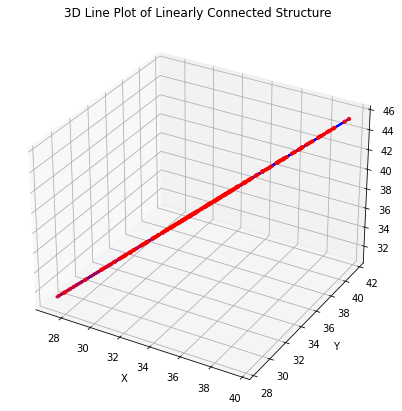

In [7]:
### Plot a random RNA molecule 3D structures
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Load the CSV file
df = pd.read_csv('./sample_submission_predicted.csv')

df['mol_prefix'] = df['ID'].str.rsplit('_', n=1).str[0]
unique_molecules = df['mol_prefix'].unique()

#np.random.seed(42)  # 42 is just a commonly used example
seed = np.random.randint(0, 100000)
np.random.seed(seed)

selected_mol = np.random.choice(unique_molecules)
print("Randomly selected molecule:", selected_mol, "\nRandom seed: ", seed)
 
# Filter for rows that belong to molecule 1SCL_A
df_1scl = df[df['ID'].str.startswith(selected_mol)]

# Sort by resid if not already sorted
df = df_1scl.sort_values(by='resid')

# Create a 3D line plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the line connecting the points
ax.plot(df['x_1'], df['y_1'], df['z_1'], color='blue', linewidth=2)

# Optionally scatter points on top for clarity
ax.scatter(df['x_1'], df['y_1'], df['z_1'], color='red',s=10)

# Axis labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Line Plot of Linearly Connected Structure')

fig.savefig('sample_submission_'+selected_mol+'.pdf', format='pdf')
plt.show()
